In [128]:
from two_player_games.games.isolation import Isolation, IsolationMove, IsolationState

def play_game():
    game = Isolation(size=5)  # you can change size
    state = game.state

    while not state.is_finished():
        print(state)

        moves = list(state.get_moves())
        print("\nAvailable moves:", [m.field for m in moves])

        # Ask user for move
        move_input = int(input("Choose field index: "))

        move = IsolationMove(move_input)

        if move not in moves:
            print("Invalid move, try again.")
            continue

        state = state.make_move(move)

    print(state)

In [129]:
from two_player_games.player import Player
from typing import Optional
import math
import random

class IsolationAI:
    def __init__(self, player: Player, depth: int) -> None:
        self.player = player
        self.depth = depth

    def evaluate(self, state: IsolationState) -> int:
        if state.is_finished():
            winner = state.get_winner()
            if winner == self.player:
                return 1_000
            elif winner is None:
                return 0
            else:
                return -1_000

        player_moves = len(list(state.get_moves_for_player(self.player)))

        opponent = state.other_player if state.current_player == self.player else state.current_player
        opponent_moves = len(list(state.get_moves_for_player(opponent)))

        return 2 * player_moves - opponent_moves

    def minimax_with_pruning(
        self,
        state: IsolationState,
        depth: int,
        alpha: float,
        beta: float,
        player_turn: Player
    ) -> tuple[float, Optional[IsolationMove]]:
        if depth == 0 or state.is_finished():
            return self.evaluate(state), None

        moves = list(state.get_moves_for_player(player_turn))
        if not moves:
            return self.evaluate(state), None

        best_moves: list[IsolationMove] = []
        best_eval = -math.inf if player_turn == self.player else math.inf

        for move in moves:
            new_state = state.make_move(move)
            eval_score, _ = self.minimax_with_pruning(
                new_state, depth-1, alpha, beta, new_state.current_player
            )

            if (player_turn == self.player and eval_score > best_eval) or \
            (player_turn != self.player and eval_score < best_eval):
                best_eval = eval_score
                best_moves = [move]
            elif eval_score == best_eval:
                best_moves.append(move)

            if player_turn == self.player:
                alpha = max(alpha, eval_score)
            else:
                beta = min(beta, eval_score)

            if beta <= alpha:
                break

        return best_eval, random.choice(best_moves)

    def choose_move(self, state: IsolationState) -> Optional[IsolationMove]:
        _, move = self.minimax_with_pruning(
            state=state,
            depth=self.depth,
            alpha=-math.inf,
            beta=math.inf,
            player_turn=state.current_player
        )
        return move

In [130]:
from typing import cast

game = Isolation(size=3)
state: IsolationState = cast(IsolationState, game.state)
ai = IsolationAI(player=state.current_player, depth=5)

while not state.is_finished():
    print(state)
    move = ai.choose_move(state)
    if move:
        print(f"AI chooses: {move.field}")
        state = state.make_move(move)
print(state)


[O]| 1 | 2 
-----------
 3 | 4 | 5 
-----------
 6 | 7 |[X]

Current player: O
AI chooses: 4

 O | 1 | 2 
-----------
 3 |[O]| 5 
-----------
 6 | 7 |[X]

Current player: X
AI chooses: 7

 O | 1 | 2 
-----------
 3 |[O]| 5 
-----------
 6 |[X]| X 

Current player: O
AI chooses: 2

 O | 1 |[O]
-----------
 3 | O | 5 
-----------
 6 |[X]| X 

Current player: X
AI chooses: 5

 O | 1 |[O]
-----------
 3 | O |[X]
-----------
 6 | X | X 

Current player: O
AI chooses: 1

 O |[O]| O 
-----------
 3 | O |[X]
-----------
 6 | X | X 

Winner: Player O


In [131]:
class IsolationRunner:
    def __init__(
        self,
        size: int = 5,
        human_player: Optional[Player] = None,
        ai_depth: Optional[int] = None,
        ai_depths: Optional[tuple[int, int]] = None,
        random_beginning: bool = False
    ):
        self.human_player = human_player
        self.ai1: Optional[IsolationAI] = None
        self.ai2: Optional[IsolationAI] = None

        if human_player and ai_depth is not None:
            ai_player = Player("X")
            first, second = human_player, ai_player

        elif ai_depths is not None:
            first = Player("O")
            second = Player("X")

        else:
            first = Player("O")
            second = Player("X")

        if random_beginning:
            if random.choice([True, False]):
                first, second = second, first

        self.first_player = first
        self.second_player = second

        self.game = Isolation(size=size, first_player=first, second_player=second)
        self.state = cast(IsolationState, self.game.state)

        # Create AI(s) if needed
        if human_player and ai_depth is not None:
            self.ai1 = IsolationAI(ai_player, depth=ai_depth)
        elif ai_depths is not None:
            depth1, depth2 = ai_depths
            self.ai1 = IsolationAI(first, depth=depth1)
            self.ai2 = IsolationAI(second, depth=depth2)

    def play(self, do_prints:bool = True):
        while not self.state.is_finished():
            if do_prints:
                print(self.state)
            current_player = self.state.current_player
            move = None

            # Human move
            if self.human_player and current_player == self.human_player:
                moves = list(self.state.get_moves())
                while move not in moves:
                    inp = input(f"Available moves {[m.field for m in moves]}. Enter move for {current_player.char}: ")
                    try:
                        move_input = int(inp)
                        move = IsolationMove(move_input)
                        if move not in moves:
                            if do_prints:
                                print("Invalid move. Try again.")
                    except ValueError:
                        if "x" in str(inp):
                            return
                        if do_prints:
                            print("Enter a valid number.")

            # AI moves
            elif self.ai1 and current_player == self.ai1.player:
                move = self.ai1.choose_move(self.state)
                assert move
                if do_prints:
                    print(f"AI1 (depth: {self.ai1.depth}) ({current_player.char}) chooses: {move.field}")

            elif self.ai2 and current_player == self.ai2.player:
                move = self.ai2.choose_move(self.state)
                assert move
                if do_prints:
                    print(f"AI2 (depth: {self.ai2.depth}) ({current_player.char}) chooses: {move.field}")

            # Human vs human fallback
            else:
                moves = list(self.state.get_moves())
                while move not in moves:
                    inp = input(f"Available moves {[m.field for m in moves]}. Enter move for {current_player.char}: ")
                    try:
                        move_input = int(inp)
                        move = IsolationMove(move_input)
                        if move not in moves:
                            print("Invalid move. Try again.")
                    except ValueError:
                        if "x" in str(inp):
                            return
                        if do_prints:
                            print("Enter a valid number.")

            # Apply the move
            assert move
            self.state = self.state.make_move(move)

        if do_prints:
            print(self.state)

        winner = self.state.get_winner()
        if winner is None:
            return None
        elif winner == self.first_player:
            return 0
        else:
            return 1

In [132]:
human = Player("O")
runner = IsolationRunner(
    size=3,
    human_player=human,
    ai_depth=5
)
runner.play()


[O]| 1 | 2 
-----------
 3 | 4 | 5 
-----------
 6 | 7 |[X]

Current player: O


In [133]:
runner = IsolationRunner(
    size=6,
    ai_depths=(3, 10)
)
runner.play()


[O]| 1 | 2 | 3 | 4 | 5 
-----------------------
 6 | 7 | 8 | 9 |10 |11 
-----------------------
12 |13 |14 |15 |16 |17 
-----------------------
18 |19 |20 |21 |22 |23 
-----------------------
24 |25 |26 |27 |28 |29 
-----------------------
30 |31 |32 |33 |34 |[X]

Current player: O
AI1 (depth: 3) (O) chooses: 1

 O |[O]| 2 | 3 | 4 | 5 
-----------------------
 6 | 7 | 8 | 9 |10 |11 
-----------------------
12 |13 |14 |15 |16 |17 
-----------------------
18 |19 |20 |21 |22 |23 
-----------------------
24 |25 |26 |27 |28 |29 
-----------------------
30 |31 |32 |33 |34 |[X]

Current player: X
AI2 (depth: 10) (X) chooses: 34

 O |[O]| 2 | 3 | 4 | 5 
-----------------------
 6 | 7 | 8 | 9 |10 |11 
-----------------------
12 |13 |14 |15 |16 |17 
-----------------------
18 |19 |20 |21 |22 |23 
-----------------------
24 |25 |26 |27 |28 |29 
-----------------------
30 |31 |32 |33 |[X]| X 

Current player: O
AI1 (depth: 3) (O) chooses: 8

 O | O | 2 | 3 | 4 | 5 
-----------------------
 6 | 7 

0

In [134]:
from tqdm import tqdm
import matplotlib.pyplot as plt

class IsolationMultiSim:
    """
    Runs multiple AI vs AI Isolation games and collects win statistics.
    """
    def __init__(self, size: int = 5):
        self.size = size
        self.results = []

    def run_duel(
        self,
        depth_pair: tuple[int, int],
        n_games: int = 50,
        random_beginning: bool = True,
    ):
        """
        Runs n_games for a single AI duel (depth1 vs depth2).
        Returns a dictionary with wins and difference.
        """
        depth1, depth2 = depth_pair
        wins_ai1 = 0
        wins_ai2 = 0

        for _ in tqdm(range(n_games), desc=f"Depth {depth1} vs {depth2}"):
            runner = IsolationRunner(
                size=self.size,
                ai_depths=(depth1, depth2),
                random_beginning=random_beginning
            )
            result = runner.play(do_prints=False)
            if result == 0:
                wins_ai1 += 1
            elif result == 1:
                wins_ai2 += 1

        duel_result = {
            "depth_pair": depth_pair,
            "wins_ai1": wins_ai1,
            "wins_ai2": wins_ai2,
            "difference": wins_ai1 - wins_ai2,
            "total_games": wins_ai1 + wins_ai2
        }

        self.results.append(duel_result)
        return duel_result

    def plot_duel_result(self, duel_result):
        depth1, depth2 = duel_result["depth_pair"]
        wins_ai1 = duel_result["wins_ai1"]
        wins_ai2 = duel_result["wins_ai2"]
        difference = duel_result["difference"]
        total_games = duel_result["total_games"]

        x = [0]  # single duel position

        fig, ax = plt.subplots(figsize=(8, 6))

        # Gray background for total games (±total_games)
        ax.bar(x, [total_games], color="lightgray", alpha=0.3, label="Total games")
        ax.bar(x, [-total_games], color="lightgray", alpha=0.3)

        # AI1 and AI2 wins
        ax.bar(x, [wins_ai1], color="green", alpha=0.7, label="AI1 wins")
        ax.bar(x, [-wins_ai2], color="red", alpha=0.7, label="AI2 wins")

        # Difference as a point
        ax.scatter(x, [difference], color="blue", s=120, zorder=5, label="Difference (AI1-AI2)")

        # Labels, title, grid
        ax.set_xticks([0])
        ax.set_xticklabels([f"{depth1}v{depth2}"])
        ax.set_ylim(-total_games, total_games)
        ax.set_ylabel("Games")
        ax.set_title(f"Isolation AI Duel: Depth {depth1} vs {depth2}")
        ax.legend()
        ax.grid(axis="y", linestyle="--", alpha=0.5)

        plt.show()

Depth 5 vs 3: 100%|██████████| 100/100 [00:02<00:00, 37.52it/s]


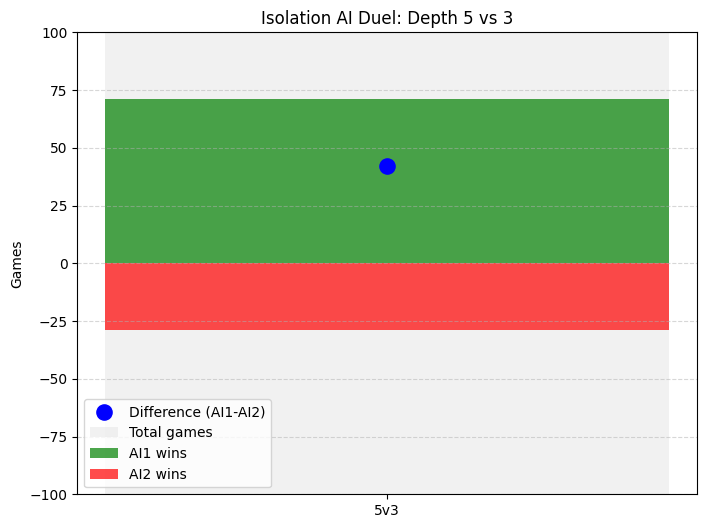

In [143]:
if __name__ == "__main__":
    sim = IsolationMultiSim(size=5)
    results = sim.run_duel((5, 3), n_games=100)
    sim.plot_duel_result(results)